In [158]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt 
%matplotlib inline 
import matplotlib
matplotlib.rcParams["figure.figsize"]=(20,10)
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor 
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r'C:\Users\user\Desktop\Bengaluru_House_Data.csv')

In [3]:
df.shape

(13320, 9)

In [4]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


# Data Cleaning 

In [5]:
# Removing unnecessary features 
df1 = df.drop(['area_type','availability','society'], axis = 'columns')

In [6]:
df1.head()

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [7]:
df1.isnull().sum()

location        1
size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

In [8]:
df2 = df1.dropna()

In [9]:
df2.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

In [13]:
df2['bhk'] = df2['size'].apply(lambda x: int(x.split(' ')[0]))

In [14]:
df2.head(2)

,location,size,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,4


In [29]:
df2 = df2.drop(['size'], axis = 1)
df2.head(3)

,location,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Uttarahalli,1440,2.0,3.0,62.00,3


# Defining a function to check if a value is not a float

In [31]:
def is_not_float(x):
    try:
        float(x)
    except:
         return True
    return False

In [32]:
df2['total_sqft'].values[2]

'1440'

In [33]:
df2[df2['total_sqft'].apply(is_not_float)].shape

(186, 6)

# Function to define the mean of total sqft

In [34]:
def convert_sqft_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

In [35]:
df3 = df2.copy()

In [36]:
df3['total_sqft'] = df3.total_sqft.apply(convert_sqft_num)

In [30]:
df3.head(10)

,location,size,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,1.0,51.00,2
5,Whitefield,2 BHK,1170.0,2.0,1.0,38.00,2
8,Marathahalli,3 BHK,1310.0,3.0,1.0,63.25,3
10,Whitefield,3 BHK,1800.0,2.0,2.0,70.00,3
11,Whitefield,4 Bedroom,2785.0,5.0,3.0,295.00,4
12,7th Phase JP Nagar,2 BHK,1000.0,2.0,1.0,38.00,2


In [37]:
df3[df3['total_sqft'].apply(is_not_float)].head(5)

,location,total_sqft,bath,balcony,price,bhk


In [38]:
df3['total_sqft'].isnull().sum()

42

In [39]:
df3.isnull().sum()

location       0
total_sqft    42
bath           0
balcony        0
price          0
bhk            0
dtype: int64

In [40]:
df3 = df3[df3.total_sqft.notnull()]
df3.head()

,location,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3
4,Kothanur,1200.0,2.0,1.0,51.00,2


In [41]:
df3.isnull().sum()

location      0
total_sqft    0
bath          0
balcony       0
price         0
bhk           0
dtype: int64

In [43]:
df4.head(2)

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4


# Creating new feature price_per_sqft 

In [43]:
df5 = df3.copy()

In [44]:
df5['price_per_sqft'] = df3['price']*100000/df3['total_sqft']

In [45]:
df5.head(3)

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,4615.384615
2,Uttarahalli,1440.0,2.0,3.0,62.00,3,4305.555556


## Cleaning location values

In [46]:
df.location.values

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       'Raja Rajeshwari Nagar', 'Padmanabhanagar', 'Doddathoguru'],
      dtype=object)

In [47]:
len(df.location.unique())

1306

# We want to count the frequency for each location 

In [50]:
df5.location = df5.location.apply(lambda x: x.strip())
location_stats = df5['location'].value_counts(ascending = False)
location_stats

Whitefield           514
Sarjapur  Road       372
Electronic City      302
Kanakpura Road       259
Thanisandra          233
                    ... 
Subbannaiah Palya      1
whitefiled             1
Medi Agrahara          1
Sadduguntepalya        1
Abshot Layout          1
Name: location, Length: 1248, dtype: int64

In [53]:
location_stats_under10 = location_stats[location_stats <= 10]
location_stats_under10.sum()

2741

### Grouping all location names with a frequency below 10 into a single category called "Other"

In [82]:
df5.location = df5.location.apply(lambda x: 'other' if x in location_stats_under10 else x)
df5[df5['location'] == 'other'].head()

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
18,other,2770.0,4.0,2.0,290.0,3,10469.314079
19,other,1100.0,2.0,2.0,48.0,2,4363.636364
25,other,1250.0,3.0,2.0,56.0,3,4480.000000
42,other,600.0,1.0,0.0,38.0,1,6333.333333
49,other,869.0,2.0,1.0,36.0,2,4142.692750


# Removing ourtliers 

In [59]:
df5 = df5[~(df5.total_sqft/df5.bhk < 300)]

In [60]:
df5.shape

(12013, 7)

In [61]:
df5.price_per_sqft.describe()

count     12013.000000
mean       6206.082347
std        3985.518807
min         267.829813
25%        4199.363057
50%        5252.525253
75%        6823.529412
max      176470.588235
Name: price_per_sqft, dtype: float64

The large difference between the minimum and maximum values indicates the potential presence of outliers.

## Defining a function to remove outliers

In [62]:
def outlier_removal_mst(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        mean = np.mean(subdf.price_per_sqft)
        std = np.std(subdf.price_per_sqft)
        reduced_subdf = subdf[(subdf.price_per_sqft>(mean-std)) & (subdf.price_per_sqft<=(mean+std))]
        df_out = pd.concat([df_out, reduced_subdf], ignore_index = True)
    return df_out

In [63]:
df6 = outlier_removal_mst(df5)

In [64]:
df6.price_per_sqft.describe()

count     9852.000000
mean      5587.667247
std       2170.551920
min       1250.000000
25%       4225.352113
50%       5142.857143
75%       6355.616616
max      24000.000000
Name: price_per_sqft, dtype: float64

After outlier removal, the range of the data has been reduced, resulting in more consistent minimum and maximum values.

In [65]:
df6.head()

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4,15017.543860
1,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3,11901.840491
2,1st Block Jayanagar,1875.0,2.0,3.0,235.0,3,12533.333333
3,1st Block Jayanagar,1200.0,2.0,0.0,130.0,3,10833.333333
4,1st Block Jayanagar,1235.0,2.0,2.0,148.0,2,11983.805668


# Data Visualisation 

### Plotting total square footage vs. price per square foot for properties with the same location and number of bedrooms 'BHK'

In [66]:
def plot_scatter_chart(df, location):
    bhk2 = df[(df.location == location) & (df.bhk == 2)]
    bhk3 = df[(df.location == location) & (df.bhk == 3)]
    matplotlib.rcParams['figure.figsize'] = (20,10)
    plt.scatter(bhk2.total_sqft, bhk2.price_per_sqft, color = 'blue', label = '2 BHK', s = 50)
    plt.scatter(bhk3.total_sqft, bhk3.price_per_sqft, color = 'red', label = '3 BHK', s = 50)
    plt.xlabel('total_sqft')
    plt.ylabel('price_per_sqft')
    plt.title(location)
    plt.legend()

### Plotting total square footage vs. price for properties with the same location and number of bedrooms.

In [61]:
def plot_scatter_chart1(df, location):
    bhk2 = df[(df.location == location) & (df.bhk == 2)]
    bhk3 = df[(df.location == location) & (df.bhk == 3)]
    matplotlib.rcParams['figure.figsize'] = (20,10)
    plt.scatter(bhk2.total_sqft, bhk2.price, color = 'blue', label = '2 BHK', s = 50)
    plt.scatter(bhk3.total_sqft, bhk3.price, color = 'red', label = '3 BHK', s = 50)
    plt.xlabel('total_sqft')
    plt.ylabel('price')
    plt.title(location)
    plt.legend()

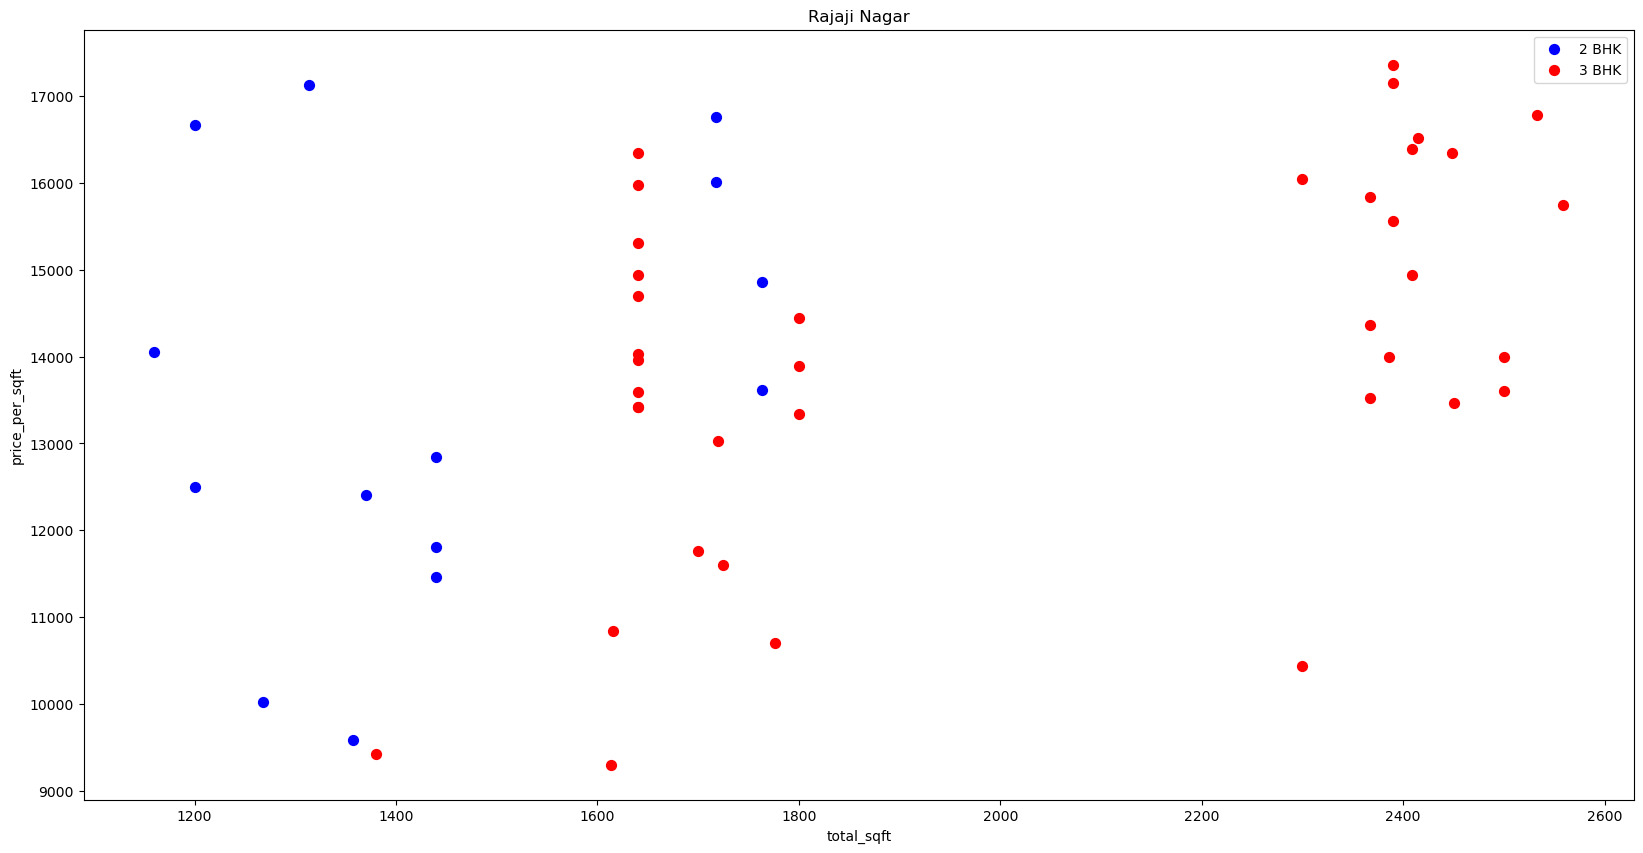

In [62]:
plot_scatter_chart(df6, 'Rajaji Nagar')

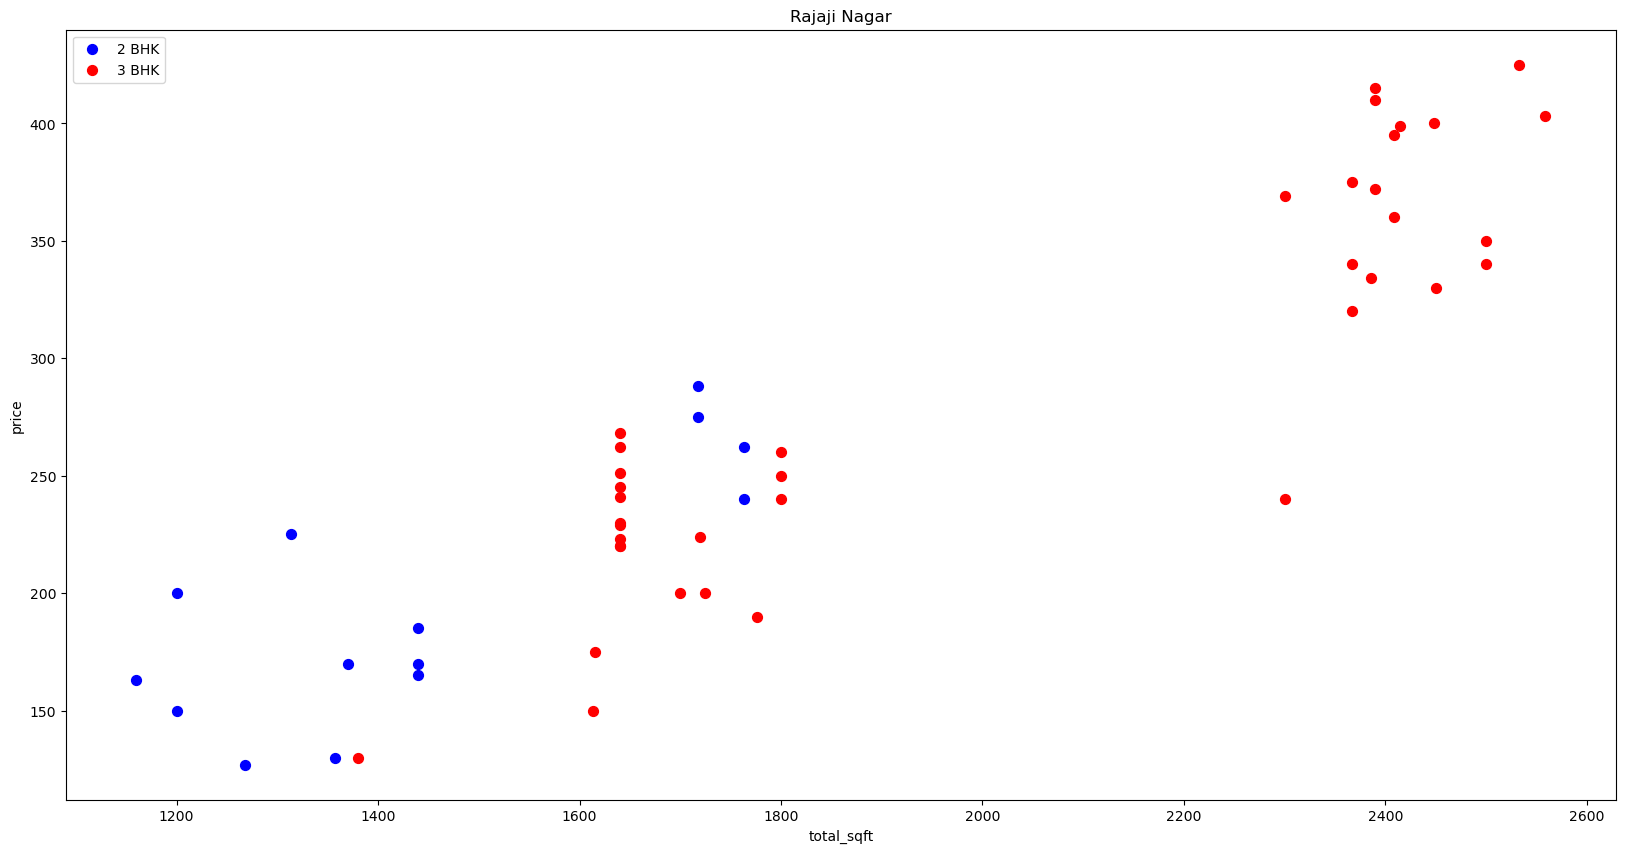

In [63]:
plot_scatter_chart1(df6, 'Rajaji Nagar')

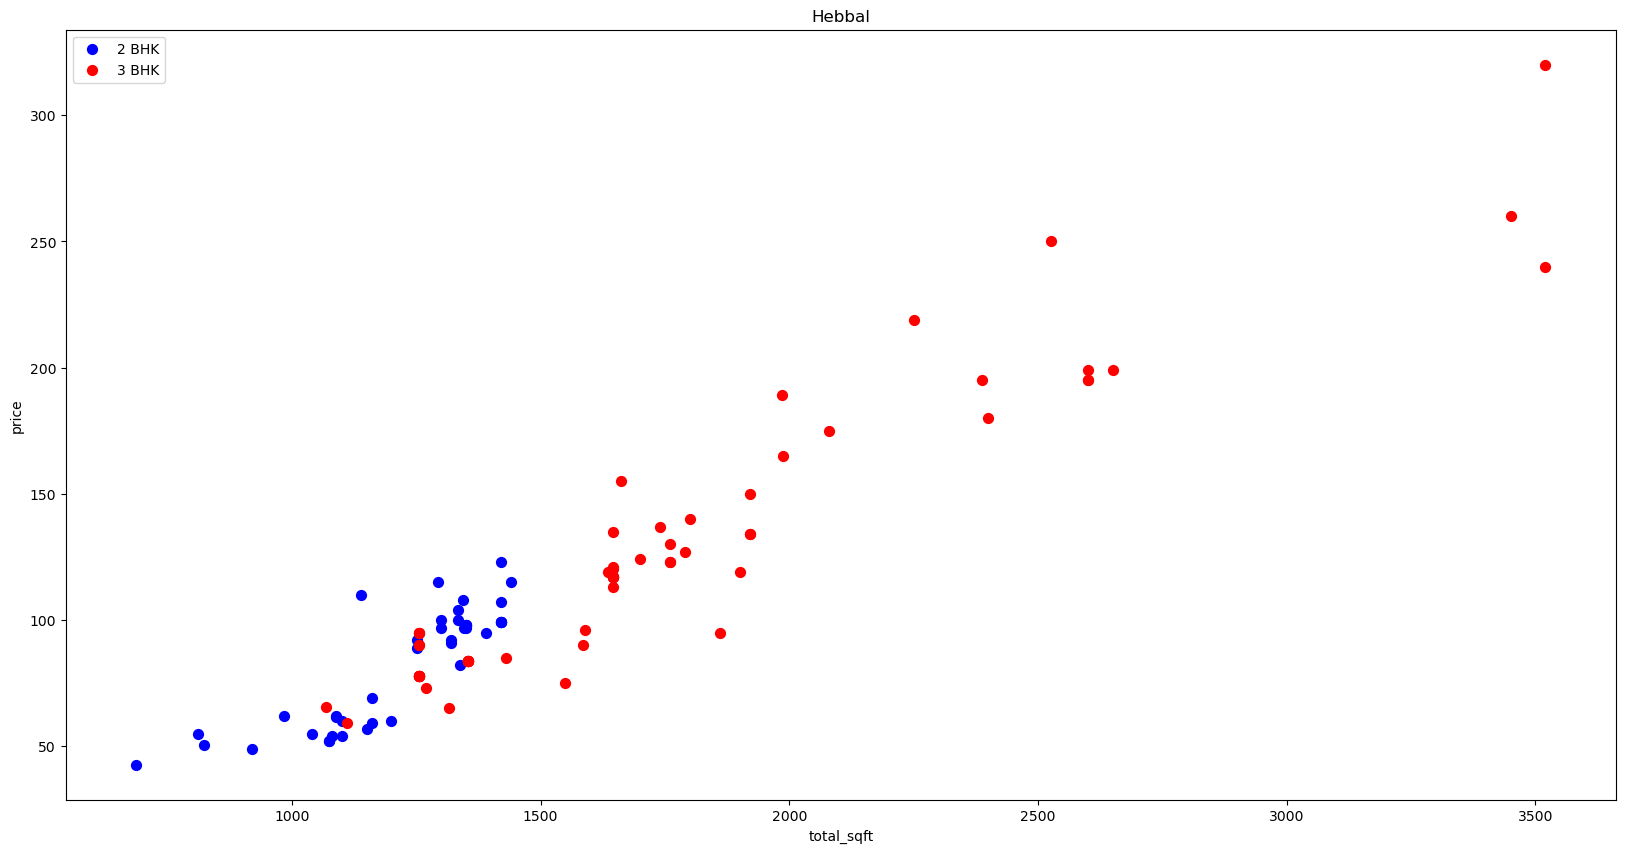

In [64]:
plot_scatter_chart1(df6, 'Hebbal')

Houses with 3 bedrooms tend to exhibit larger sizes and higher prices, which is expected; however, the data still contains some outliers.

# A dictionary to remove outliers where, for the same location and number of bedrooms, the price per square foot is not consistent with the mean and standard deviation

In [68]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
             bhk_stats[bhk] = {
                 'mean': np.mean(bhk_df.price_per_sqft),
                 'std': np.std(bhk_df.price_per_sqft),
                 'count': bhk_df.shape[0]
             }
  
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices, axis = 'index')           

In [84]:
df7 = remove_bhk_outliers(df6)

In [70]:
df7.shape

(7014, 7)

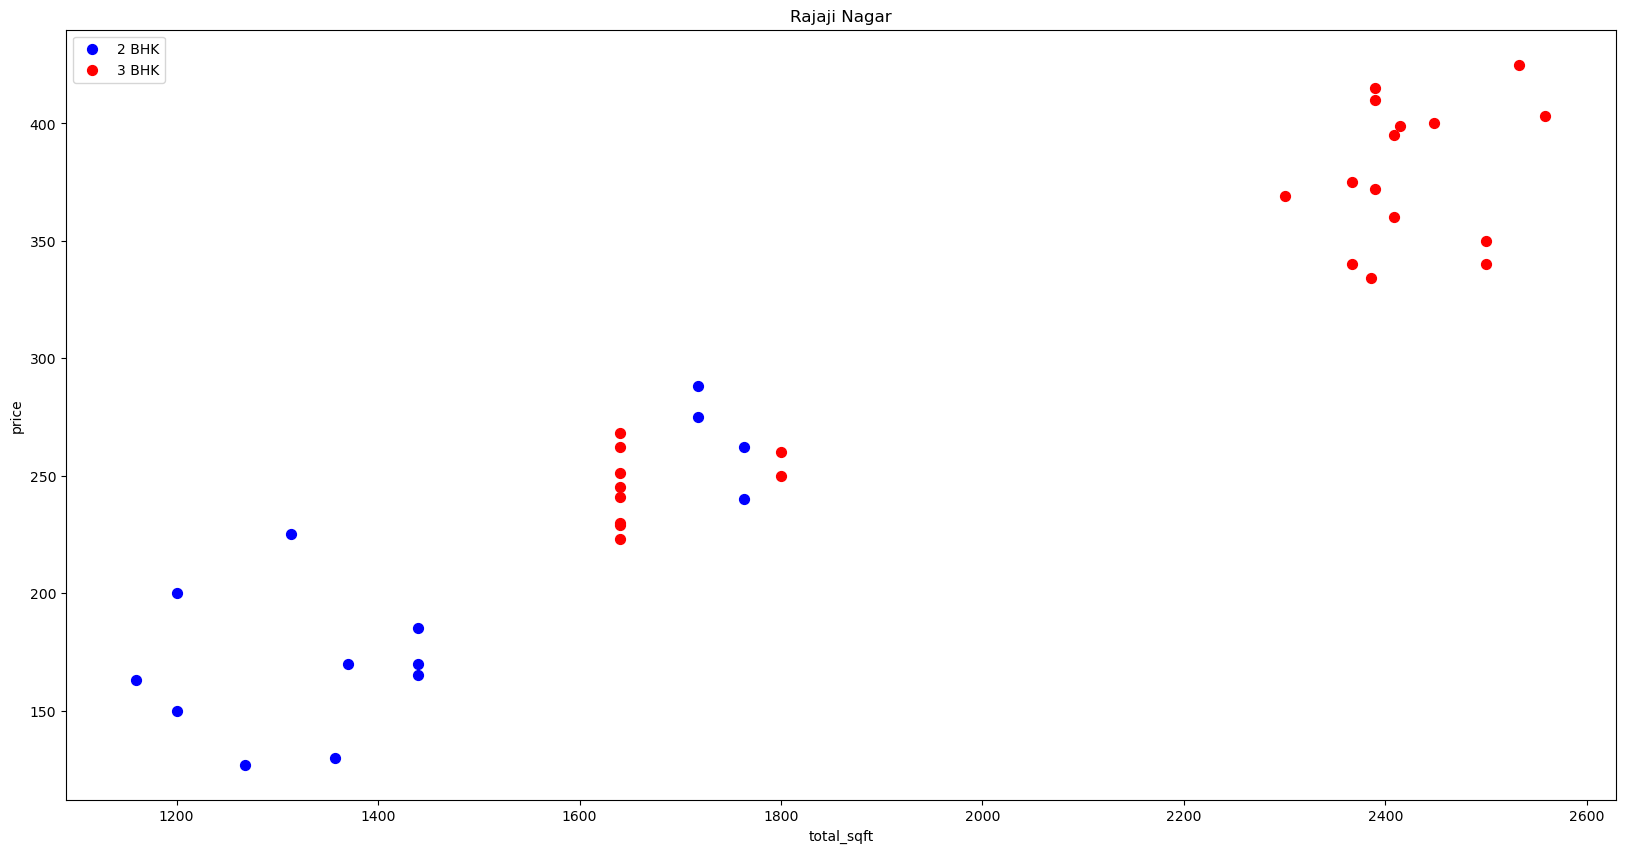

In [68]:
plot_scatter_chart1(df7, 'Rajaji Nagar')

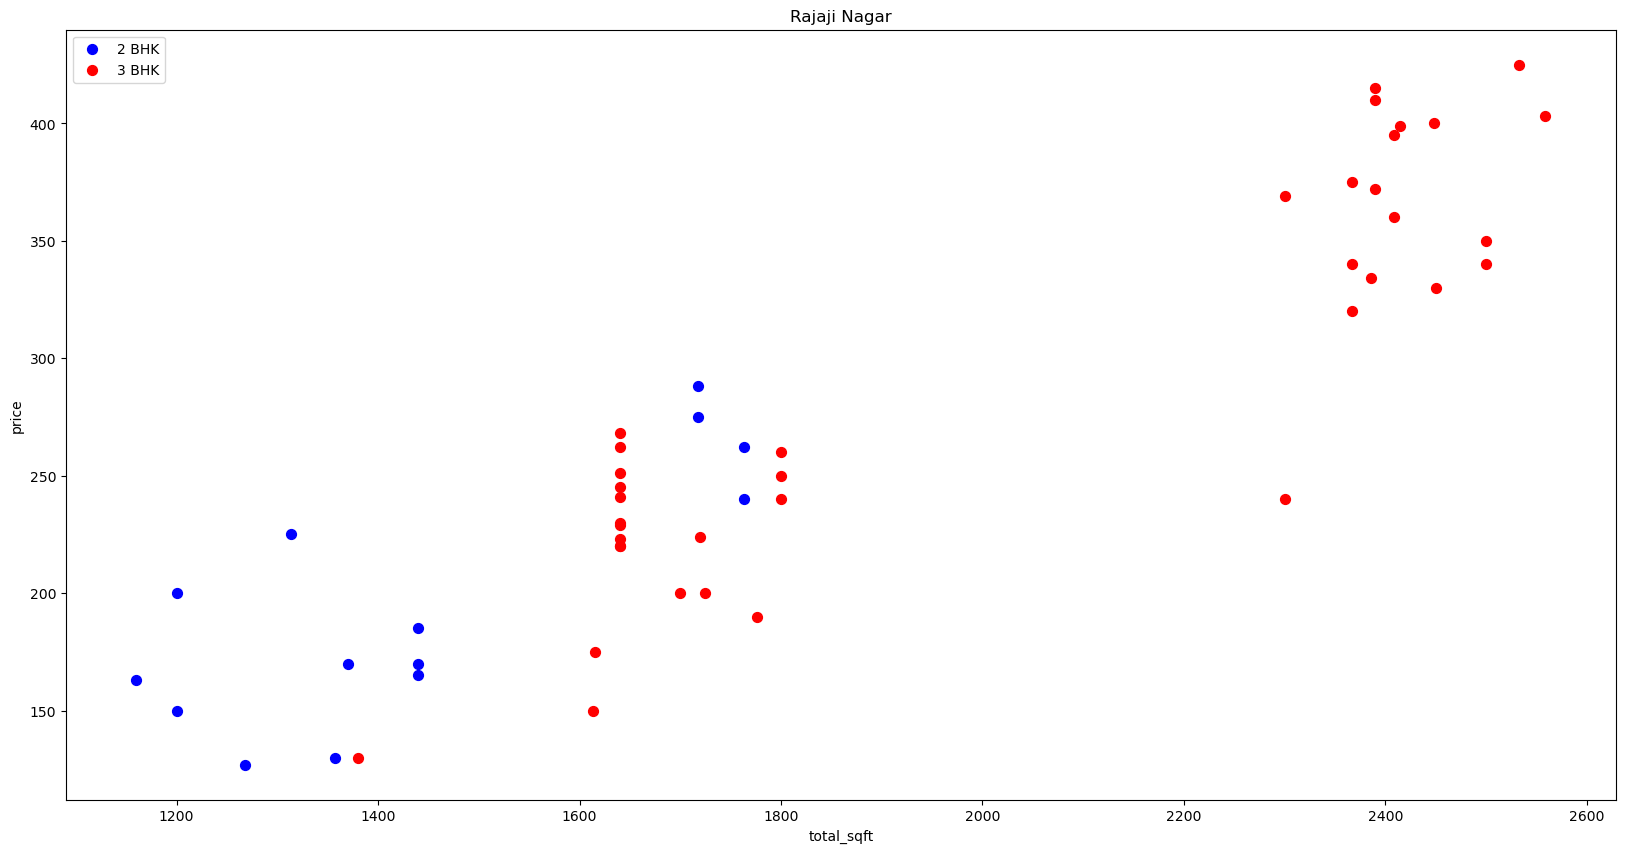

In [69]:
plot_scatter_chart1(df6, 'Rajaji Nagar')

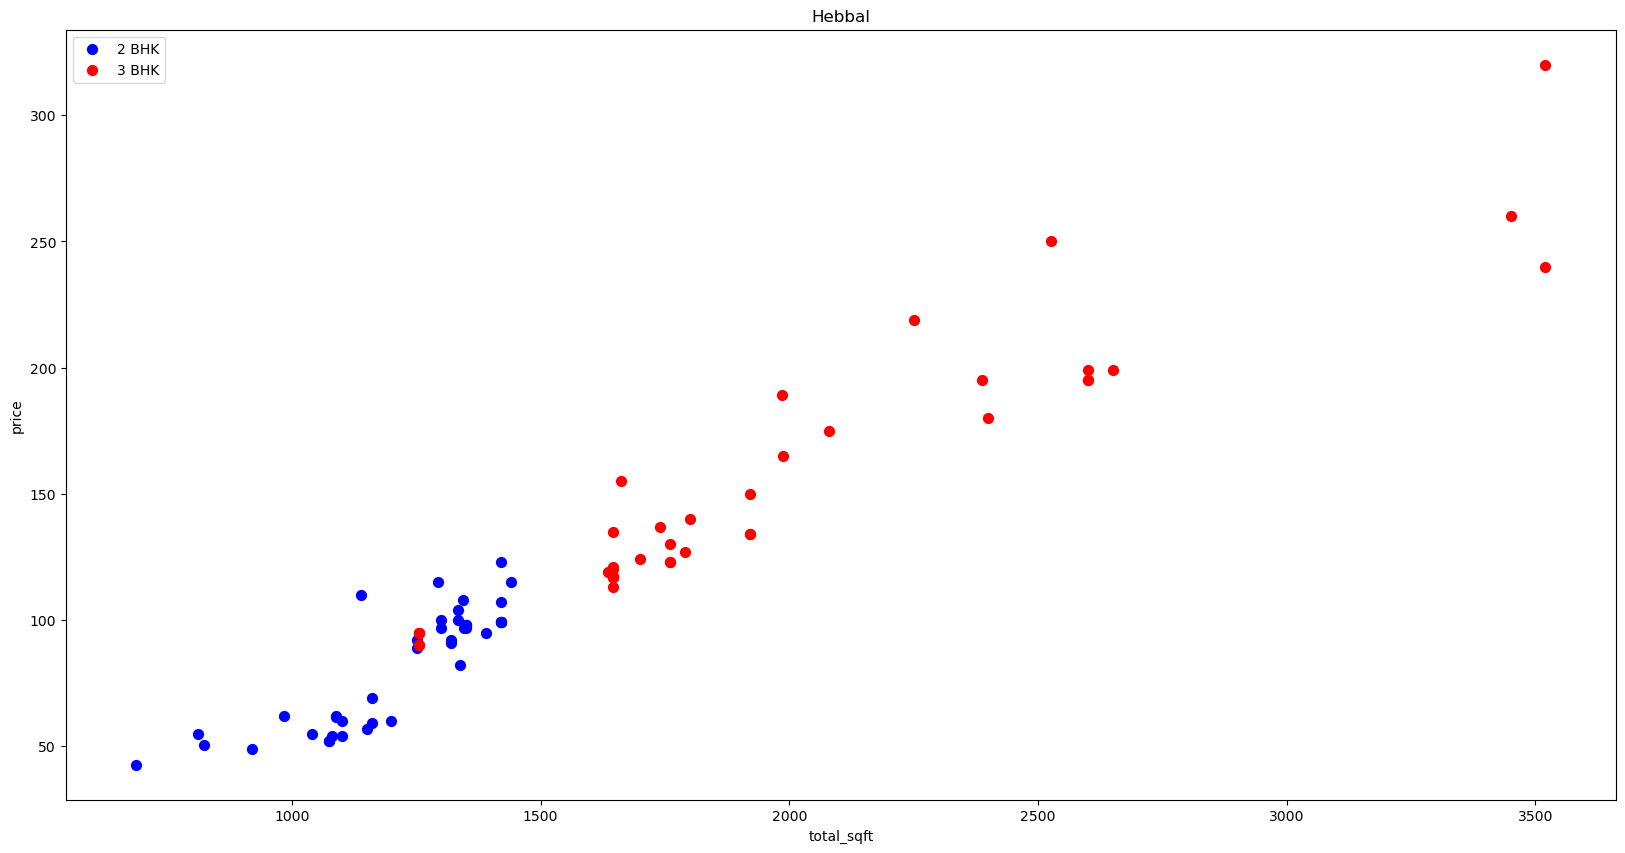

In [71]:
plot_scatter_chart1(df7, 'Hebbal')

We can observe that the presence of outliers has been reduced, but they have not been completely eliminated. 

### Histogram of price_per_sqft

Text(0, 0.5, 'Count')

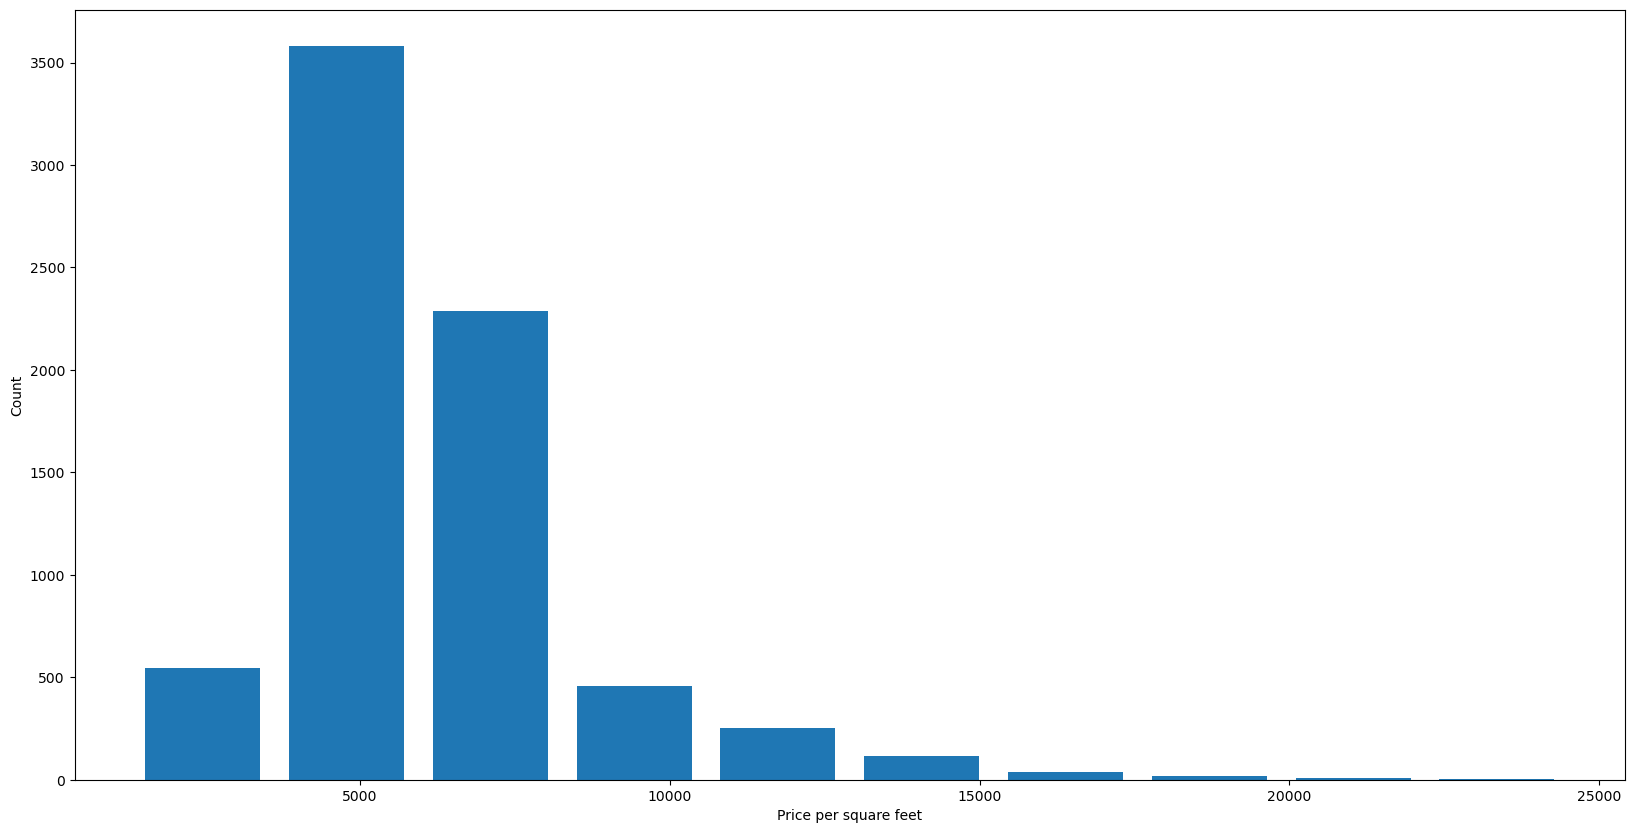

In [72]:
import matplotlib 
matplotlib.rcParams["figure.figsize"]=(20,10)
plt.hist(df7.price_per_sqft, rwidth=0.8)
plt.xlabel('Price per square feet')
plt.ylabel('Count')

We observe that the price per square foot for most houses is around 5000.

# Detecting outliers in bathrooms

In [85]:
df7.bath.unique()

array([ 4.,  3.,  2.,  8.,  1.,  5.,  6.,  7.,  9., 13.])

In [86]:
df7[df7.bath>10]

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
9267,other,5425.0,13.0,0.0,275.0,13,5069.124424


In [88]:
df7[df7.bath> df7.bhk+1]

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
33,2nd Stage Nagarbhavi,3000.0,8.0,3.0,451.0,6,15033.333333
34,2nd Stage Nagarbhavi,2400.0,8.0,3.0,450.0,6,18750.000000
506,Arekere,2710.0,6.0,2.0,142.0,4,5239.852399
553,BTM 2nd Stage,1260.0,5.0,1.0,185.0,3,14682.539683
785,Bannerghatta,3012.0,6.0,2.0,250.0,4,8300.132802
...,...,...,...,...,...,...,...
9538,other,6652.0,6.0,1.0,510.0,4,7666.867108
9656,other,600.0,4.0,1.0,70.0,2,11666.666667
9708,other,5656.0,5.0,0.0,499.0,3,8822.489392
9815,other,6652.0,6.0,1.0,660.0,4,9921.828022


In [90]:
df8 = df7[df7.bath < df7.bhk+1]
df8.bath.unique()

array([ 4.,  3.,  2.,  1.,  5.,  6.,  8.,  7.,  9., 13.])

In [91]:
df9 = df8.drop(['price_per_sqft'], axis = 1)
df9.head(2)

,location,total_sqft,bath,balcony,price,bhk
0,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3


# One hot encoding or dummies for 'Location'

In [92]:
dummies = pd.get_dummies(df9.location)
dummies = dummies.drop('other', axis = 'columns')
dummies.head(2)

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,AECS Layout,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [93]:
df10 = pd.concat([df9, dummies], axis = 'columns')
df10.head(2)

,location,total_sqft,bath,balcony,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,1.0,428.0,4,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1st Block Jayanagar,1630.0,3.0,2.0,194.0,3,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [94]:
df10.shape

(6612, 241)

# Machine Learning Model 

In [95]:
x = df10.drop(['price', 'location'], axis = 'columns')
y = df10.price

### Evaluate multiple regression models and return the best model using GridSearchCV and cross-validation

In [131]:
def find_best_model_using_gridsearchcv(X,Y):
    
    algos = {
        'linear_regression':  {
            'model': LinearRegression(),
            'params': {
                'copy_X' : [True, False],
                'fit_intercept' : [True, False],
                'n_jobs' : [1,2,3],
                'positive' : [True, False]
            }
        },
        'lasso':  {
            'model': Lasso(),
            'params': {
                'alpha': [1,2],
                'selection': ['random', 'cyclic']
            }
        },
        'decision_tree':  {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['mse', 'friedman_mse'],
                'splitter': ['best', 'random']
            }}}
    
    scores = []
    
    cv = ShuffleSplit(n_splits=5, test_size = 0.2, random_state = 0)
    
    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], cv = cv, return_train_score = False)
        gs.fit(x,y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_})
        return scores #pd.DataFrame(scores, columns = ['model', 'best_score', 'best_params'])

In [132]:
find_best_model_using_gridsearchcv(x,y)

[{'model': 'linear_regression',
  'best_score': 0.8523475961798315,
  'best_params': {'copy_X': True,
   'fit_intercept': False,
   'n_jobs': 1,
   'positive': False}}]

## Best model 

In [140]:
def Best_model(X, y):
    model = LinearRegression(
        copy_X=True,
        fit_intercept=False,
        n_jobs=1,
        positive=False
    )
    model.fit(x, y)
    return model

lgr = Best_model(x,y)

# Prediction function

In [141]:
def predict_price(location, sqft, bath, bhk):
    
    loc_index = np.where(x.columns==location)[0][0]
    
    n = np.zeros(len(x.columns))
    n[0] = sqft
    n[1] = bath
    n[2] = bhk
    
    if loc_index >= 0:
        n[loc_index] = 1
    
    return lgr.predict([n])[0]

In [160]:
predicted_price = predict_price('1st Block Jayanagar', 1000, 2, 2)
display(Markdown(f"**Predicted price is: {predicted_price}**"))

**Predicted price is: 189.402669845196**